# 02_Finetune_Gemma3_Multimodal_From_HF_Dataset

이 노트북은 Hugging Face에 업로드한 통합 데이터셋을 내려받아,
Gemma 3 멀티모달 포맷으로 변환한 뒤 QLoRA로 학습합니다.

- 텍스트-only 샘플도 같은 모델로 학습
- 이미지+텍스트 샘플도 같은 모델로 학습
- 배치 크기는 기본적으로 1로 두어 모달 혼합 충돌을 줄입니다.

In [27]:
import os
import random
from datasets import load_dataset
import torch
import pandas as pd
from peft import LoraConfig
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
# .env 파일에 저장된 환경 변수를 시스템에 로드
from dotenv import load_dotenv
from datetime import datetime
import huggingface_hub

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print('GPU =', torch.cuda.get_device_name(0))
print('torch =', torch.__version__)

GPU = NVIDIA RTX A5000
torch = 2.12.0+cu126


In [53]:
# .env 파일 로드 (파일이 없어도 에러가 나지 않고 False를 반환함)
load_dotenv()

# 환경 변수에서 가져오되, 없으면 기본값(Default) 사용
hf_token = os.getenv("HF_TOKEN", "YOUR_HF_TOKEN")
hf_token = "YOUR_HF_TOKEN"

In [29]:
huggingface_hub.login(hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [30]:
# ===== 사용자 설정 =====
# DATASET_REPO = 'hyokwan/multi_modal_sample'
DATASET_REPO = 'hyokwan/ocr_dataset_simple'
BASE_MODEL = 'google/gemma-3-4b-it'
# OUTPUT_DIR = '/models/gemma3_multimodal_lora_output'
OUTPUT_DIR = f"./models/gemma3_multimodal_lora_output_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
MAX_TRAIN_SAMPLES = None   # 예: 300
MAX_EVAL_SAMPLES = None    # 예: 50
MAX_SEQ_LENGTH = 768
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRAD_ACCUM = 4
NUM_EPOCHS = 5
LEARNING_RATE = 2e-4

In [31]:
ds = load_dataset(DATASET_REPO)

### 데이터셋 불러오기

In [32]:
ds = load_dataset(DATASET_REPO)
# 첫 번째 split 사용
dataset = ds[list(ds.keys())[0]]
# 8:2 분할
split_ds = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_ds = split_ds["train"]
eval_ds = split_ds["test"]

if MAX_TRAIN_SAMPLES:
    train_ds = train_ds.select(
        range(min(MAX_TRAIN_SAMPLES, len(train_ds)))
    )

if MAX_EVAL_SAMPLES:
    eval_ds = eval_ds.select(
        range(min(MAX_EVAL_SAMPLES, len(eval_ds)))
    )

print(train_ds)
print(eval_ds)
print(train_ds[0])


Dataset({
    features: ['modality', 'image', 'instruction', 'input', 'output', 'source', 'label'],
    num_rows: 104
})
Dataset({
    features: ['modality', 'image', 'instruction', 'input', 'output', 'source', 'label'],
    num_rows: 26
})
{'modality': 'image_text', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2467x3501 at 0x2479B9A56D0>, 'instruction': '이미지에서 손글씨로 작성된 텍스트를 모두 인식하여 전사하세요.', 'input': '이미지에 포함된 모든 텍스트를 공백으로 구분하여 순서대로 나열해주세요.', 'output': '09458 주 맥날 방웅우 040 2401 4474 030 9156 0041 주 내또출 020 4350 0907 080 1334 1114 남진급 537585 861568 전라북도 상당구 대랑동 삼서면 대전광역시 계양구 예천군 강원도 19 208 294 372 비담 94 2316 381536 142579 2095 44 43 1838 7232 5341 2046 79 50 조륙계 615959 203793 부 부 여성고 164351 878935 자 여 주', 'source': 'OCR_handwriting', 'label': 'P.Paper'}


# 3. 환경 및 최적화 설정 (4비트 양자화)

In [33]:
# 현재 사용 중인 GPU의 주요 아키텍처 버전을 반환 8버전 이상 시 bfloat16 활용
# NVIDIA Ampere 아키텍처 이상 시에만 처리
if torch.cuda.get_device_capability()[0] >= 8:
    # 고속 attention 메커니즘을 구현하는 라이브러리
    attn_implementation = "flash_attention_2"
    torch_dtype = torch.bfloat16
else:
    attn_implementation = "eager"
    torch_dtype = torch.float16

# BitsAndBytesConfig 객체활용 양자화 설정
quant_config = BitsAndBytesConfig(
    # 모델을 4비트 양자화하여 로드할지 여부 결정
    load_in_4bit=True,
    # 양자화 방법 (nf4: Non-Uniform Quantization, "nf4","fp16 등))
    bnb_4bit_quant_type="nf4",
    # (4비트 양자화 시 사용할 데이터 타입, "torch.float16, bfloat16, float32 등)
    bnb_4bit_compute_dtype=torch_dtype,
    # 이중 양자화 사용여부 (이중 양자화는 양자화 과정에서 정밀도 높이기 위해 활용, 대신 더 연산은 복잡)
    bnb_4bit_use_double_quant=False
)

# 4. 베이스 모델 불러오기

In [34]:
# 멀티모달 모델 로드 (이미지 + 텍스트 입력 처리 가능)
model = AutoModelForImageTextToText.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map={"":0},
    torch_dtype=torch.bfloat16,
    attn_implementation='eager',
    trust_remote_code=True,
    token = hf_token
)

# 멀티모달 모델 로드 (이미지 + 텍스트 입력 처리 가능)
processor = AutoProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True,token = hf_token)

# processor 내부에서 tokenizer만 따로 사용
tokenizer = processor.tokenizer
# pad_token 없으면 eos_token으로 설정 # 학습 시 길이 같아야 함 문장1-안녕하세요 문장2 안녕 -> 안녕[pad][pad]
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

print('pad_token_id =', tokenizer.pad_token_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

pad_token_id = 0


In [35]:
SYSTEM_MESSAGE = '당신은 멀티모달 도우미입니다. 텍스트 질문에는 정확히 답하고, 이미지가 주어지면 이미지를 보고 답하세요.'

def build_messages(example):
    instruction = str(example.get('instruction', '')).strip()
    user_input = str(example.get('input', '')).strip()
    output = str(example.get('output', '')).strip()
    modality = str(example.get('modality', 'text_only')).strip()

    user_text = f"{instruction}\n\n[입력]\n{user_input}" if instruction and user_input else (instruction or user_input)
    if not user_text:
        user_text = '주어진 정보를 바탕으로 답하세요.'

    user_content = []

    # 이미지 + 텍스트 모드이고, 실제로 이미지가 있을 때
    if modality == 'image_text' and example.get('image') is not None:
        user_content.append({
            'type': 'image',
            'image': example['image']
        })

    # 텍스트는 항상 추가
    user_content.append({
        'type': 'text',
        'text': user_text
    })

    messages = [
        {'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_MESSAGE}]},
        {'role': 'user', 'content': user_content},
        {'role': 'assistant', 'content': [{'type': 'text', 'text': output}]},
    ]
    return messages

In [36]:
# 소규모 샘플 확인
sample_rows = []
for ex in train_ds.select(range(min(4, len(train_ds)))):
    sample_rows.append({
        'modality': ex['modality'],
        'instruction': ex['instruction'][:80],
        'input': ex['input'][:80],
        'output': ex['output'][:80],
        'label': ex['label'],
        'image_present': ex['image'] is not None,
    })
pd.DataFrame(sample_rows)

,modality,instruction,input,output,label,image_present
0,image_text,이미지에서 손글씨로 작성된 텍스트를 모두 인식하여 전사하세요.,이미지에 포함된 모든 텍스트를 공백으로 구분하여 순서대로 나열해주세요.,09458 주 맥날 방웅우 040 2401 4474 030 9156 0041 주 내...,P.Paper,True
1,image_text,이미지에서 손글씨로 작성된 텍스트를 모두 인식하여 전사하세요.,이미지에 포함된 모든 텍스트를 공백으로 구분하여 순서대로 나열해주세요.,09471 턱스크 유열관 020 9920 6327 080 0594 6612 치킹스 ...,P.Paper,True
2,image_text,이미지에서 손글씨로 작성된 텍스트를 모두 인식하여 전사하세요.,이미지에 포함된 모든 텍스트를 공백으로 구분하여 순서대로 나열해주세요.,09470 갑통알 선계조 080 5295 2977 070 1117 4431 사이다 ...,P.Paper,True
3,text_only,운동 효과를 한 문장으로 설명하시오.,브릿지,엉덩이와 허리 근육을 강화한다.,,False


In [37]:
def collate_fn(examples):
    """
    텍스트 + 이미지 데이터를 모델 학습용 배치로 변환 및 불필요 토큰 학습에서 제외
    """
    texts = []
    images = []
    has_any_image = False  # 배치에 이미지가 하나라도 있는지 체크

    for example in examples:
        # 메시지 구조 생성 (user / assistant 등)
        messages = build_messages(example)

        # chat template 적용 → 모델 입력용 텍스트 생성
        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)

        # 메시지에서 이미지 추출
        example_images = []
        for item in messages[1]["content"]:  # user content 기준
            if item["type"] == "image":
                example_images.append(item["image"])

        # 이미지가 있으면 저장
        if len(example_images) > 0:
            has_any_image = True
            images.append(example_images)
        else:
            images.append([])

    # 이미지가 하나라도 있으면 text + image 같이 처리
    if has_any_image:
        batch = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
        )
    else:
        # 텍스트만 있는 경우
        batch = processor(
            text=texts,
            return_tensors="pt",
            padding=True,
        )

    # labels 생성 (input_ids 복사)
    labels = batch["input_ids"].clone()

    # pad_token은 loss 계산에서 제외 (-100은 ignore index)
    pad_token_id = processor.tokenizer.pad_token_id
    if pad_token_id is not None:
        labels[labels == pad_token_id] = -100

    # 이미지 토큰도 loss 제외
    image_token_id = getattr(model.config, "image_token_id", None)
    if image_token_id is not None:
        labels[labels == image_token_id] = -100

    # 특정 토큰(예: special token)도 loss 제외
    labels[labels == 262144] = -100

    # batch에 labels 추가
    batch["labels"] = labels

    return batch

In [38]:
examples = train_ds.select(range(0,4))
examples

Dataset({
    features: ['modality', 'image', 'instruction', 'input', 'output', 'source', 'label'],
    num_rows: 4
})

In [39]:
texts = []
images = []
has_any_image = False  # 배치에 이미지가 하나라도 있는지 체크

for example in examples:
    # 메시지 구조 생성 (user / assistant 등)
    messages = build_messages(example)

    # chat template 적용 → 모델 입력용 텍스트 생성
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    texts.append(text)

    # 메시지에서 이미지 추출
    example_images = []
    for item in messages[1]["content"]:  # user content 기준
        if item["type"] == "image":
            example_images.append(item["image"])

    # 이미지가 있으면 저장
    if len(example_images) > 0:
        has_any_image = True
        images.append(example_images)
    else:
        images.append([])

In [40]:
text

'<bos><start_of_turn>user\n당신은 멀티모달 도우미입니다. 텍스트 질문에는 정확히 답하고, 이미지가 주어지면 이미지를 보고 답하세요.\n\n운동 효과를 한 문장으로 설명하시오.\n\n[입력]\n브릿지<end_of_turn>\n<start_of_turn>model\n엉덩이와 허리 근육을 강화한다.<end_of_turn>\n'

In [41]:
# # 이미지가 하나라도 있으면 text + image 같이 처리
# if has_any_image:
#     batch = processor(
#         text=texts,
#         images=images,
#         return_tensors="pt",
#         padding=True,
#     )
# else:
#     # 텍스트만 있는 경우
#     batch = processor(
#         text=texts,
#         return_tensors="pt",
#         padding=True,
#     )

# # labels 생성 (input_ids 복사)
# labels = batch["input_ids"].clone()

# # pad_token은 loss 계산에서 제외 (-100은 ignore index)
# pad_token_id = processor.tokenizer.pad_token_id
# if pad_token_id is not None:
#     labels[labels == pad_token_id] = -100

# # 이미지 토큰도 loss 제외
# image_token_id = getattr(model.config, "image_token_id", None)
# if image_token_id is not None:
#     labels[labels == image_token_id] = -100

# # 특정 토큰(예: special token)도 loss 제외
# labels[labels == 262144] = -100

# # batch에 labels 추가
# batch["labels"] = labels

In [42]:
# # LoRA 설정 (어댑터 학습 파트)
# peft_params = LoraConfig(    
#     # LoRA 랭크(rank). 값이 클수록 학습 가능한 파라미터 증가 (성능↑ / 자원↑)
#     r=16,

#     # LoRA 스케일링 계수 (보통 r과 같거나 2배)
#     lora_alpha=32,

#     # LoRA dropout (과적합 방지)
#     lora_dropout=0.05,

#     # bias는 보통 학습하지 않음
#     bias='none',

#     # [기존 동일] Causal LM 방식 학습 (다음 토큰 예측)
#     task_type='CAUSAL_LM',

#     # [변경] 멀티모달에서는 구조가 다양해서 전체 linear layer에 적용
#     # 기존: ["q_proj", ...] → 특정 레이어 지정
#     # 지금: 'all-linear' → 모든 linear 레이어 자동 적용 (더 안전/간편)
#     target_modules='all-linear',
# )

# # SFTTrainer 학습 설정 (멀티모달 대응 버전)
# sft_args = SFTConfig(
#     output_dir="./results",

#     # (A) 학습량 / 시간 제어
#     num_train_epochs=1,  # 전체 데이터 반복 횟수

#     # GPU 1장 기준 batch size (OOM 시 가장 먼저 조정)
#     per_device_train_batch_size=1,
#     per_device_eval_batch_size=1,

#     # 유효 배치 크기 = batch_size × gradient_accumulation_steps
#     gradient_accumulation_steps=2,

#     # (B) 입력 길이 / 속도 / 메모리
#     # [멀티모달 변경] max_length → max_seq_length로 통일 (멀티모달/TRL 권장)
#     max_seq_length=256,

#     # [유지] 멀티모달에서는 packing 비추천 (구조 깨질 위험)
#     packing=False,

#     # [멀티모달 변경] 텍스트 길이 기준 묶기 → 멀티모달에서는 비추천
#     group_by_length=False,

#     # [멀티모달 제거 - 멀티모달]
#     # 텍스트 전용 SFT 옵션 (processor + collate_fn 사용 시 필요 없음)
#     # dataset_text_field="text",

#     # (C) 최적화 하이퍼파라미터
#     learning_rate=2e-4,
#     weight_decay=0.001,
#     max_grad_norm=0.3,
#     warmup_ratio=0.03,
#     lr_scheduler_type="constant",

#     # (D) 로그 / 평가 / 저장
#     logging_steps=1000,
#     report_to="tensorboard",

#     # [유지] 평가 비활성화 (속도 우선)
#     eval_strategy="no",

#     save_strategy="steps",
#     save_steps=1000,
#     save_total_limit=3,

#     # (E) 혼합정밀도 / 재현성
#     fp16=(torch_dtype == torch.float16),
#     bf16=(torch_dtype == torch.bfloat16),

#     seed=SEED,

#     # 멀티모달 필수 옵션
#     # processor로 만든 image/text 컬럼이 삭제되지 않도록 유지 true 시 image 컬럼 삭제됨
#     remove_unused_columns=False,

#     # Trainer의 자동 dataset 가공 비활성화
#     # → 우리가 만든 collate_fn 그대로 사용하기 위함 
#     dataset_kwargs={"skip_prepare_dataset": True},
# )

# trainer = SFTTrainer(
#     # 학습할 모델
#     model=model,

#     # 모델 학습에 사용할 데이터셋
#     train_dataset=train_ds,
#     eval_dataset=eval_ds,  # 평가 안 하면 None + eval_strategy="no"

#     # Peft (LoRA) 설정
#     peft_config=peft_params,

#     # [멀티모달 변경] tokenizer → processor 사용
#     # 멀티모달에서는 tokenizer만 넘기면 이미지 처리 안 됨
#     processing_class=processor,

#     # [멀티모달 추가] collate_fn 필수 (멀티모달 핵심)
#     # text + image → batch tensor 변환 담당
#     data_collator=collate_fn,

#     # 훈련 파라미터 설정
#     args=sft_args,
# )

## 5. LoRA 및 Trainer 설정

In [43]:
# LoRA 설정
peft_params = LoraConfig(    
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',

    # 멀티모달 대응 (전체 linear)
    target_modules='all-linear',
)


# SFT 설정
sft_args = SFTConfig(
    output_dir=OUTPUT_DIR,

    # (A) 학습량
    num_train_epochs=NUM_EPOCHS,

    # 하드코딩 → 상수 사용
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,   # ← 여기 중요

    # 터지지 않으려면 gpu true (입력>레이어1>레이어2>결과 시 중간 결과 저장안함) 풀이과정 안쓰고 다시 레이어 파라미터 계산
    # 종이안쓰고 그냥 바로 또계산 (vram 소모 큼)
    gradient_checkpointing=True,

    # (B) 입력 길이
    # 멀티모달이면 MAX_SEQ_LENGTH 값을 낮춰서 쓰는게 핵심
    max_seq_length=MAX_SEQ_LENGTH,

    packing=False,

    # 멀티모달에서는 True 권장
    # group_by_length=True,

    # (C) 학습 파라미터
    learning_rate=LEARNING_RATE,
    weight_decay=0.001,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="constant",

    # (D) 로그 / 평가
    logging_steps=10,
    report_to='none',

    # eval 안하면 no
    eval_strategy='no',

    save_strategy='steps',
    save_steps=100,

    # (E) mixed precision
    bf16=torch.cuda.is_available(),

    # (F) 멀티모달 필수
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
)


# Trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=None,

    peft_config=peft_params,

    # 핵심 (멀티모달)
    processing_class=processor,
    data_collator=collate_fn,

    args=sft_args,
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [44]:
trainer.train()

c:\Users\hkcode\llm_multimodal\.venv\Lib\site-packages\torch\utils\checkpoint.py:238: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Step,Training Loss
10,9.436100
20,5.162800
30,3.861100
40,3.429200
50,3.277600
60,2.988500
70,2.678000
80,2.282700
90,2.205900
100,2.303100


c:\Users\hkcode\llm_multimodal\.venv\Lib\site-packages\torch\utils\checkpoint.py:238: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


TrainOutput(global_step=130, training_loss=3.345892510047326, metrics={'train_runtime': 565.6189, 'train_samples_per_second': 0.919, 'train_steps_per_second': 0.23, 'total_flos': 5326674689273280.0, 'train_loss': 3.345892510047326})

In [45]:
OUTPUT_DIR

'./models/gemma3_multimodal_lora_output_20260611_162018'

In [46]:
def infer_unified(question, image=None, system=SYSTEM_MESSAGE, max_new_tokens=128, temperature=0.2):
    # 시스템 / 사용자 메시지 구조 생성 (멀티모달 형식)
    messages = [
        {'role': 'system', 'content': [{'type': 'text', 'text': system}]},
        {'role': 'user', 'content': []},
    ]

    # 이미지가 있으면 user 메시지에 추가
    if image is not None:
        messages[1]['content'].append({'type': 'image', 'image': image})

    # 질문 텍스트 추가
    messages[1]['content'].append({'type': 'text', 'text': question})

    # chat template 적용 → 모델 입력용 프롬프트 생성
    prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True  # 답변 생성 유도
    )

    # 이미지 포함 여부에 따라 processor 호출 방식 분기
    if image is not None:
        inputs = processor(
            text=[prompt],
            images=[[image]],  # 배치 형태 (list of list)
            return_tensors='pt',
            padding=True
        )
    else:
        inputs = processor(
            text=[prompt],
            return_tensors='pt',
            padding=True
        )

    # 모델 device(GPU/CPU)로 이동
    inputs = {
        k: v.to(model.device) if hasattr(v, 'to') else v
        for k, v in inputs.items()
    }

    # 추론 (gradient 비활성화)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,           # temperature 0이면 greedy
            temperature=max(temperature, 1e-5), # 0 division 방지
        )

    # 입력 프롬프트 이후 생성된 부분만 잘라냄
    answer_ids = outputs[:, inputs['input_ids'].shape[1]:]

    # 토큰 → 텍스트 변환
    return processor.batch_decode(
        answer_ids,
        skip_special_tokens=True
    )[0].strip()

In [47]:
# 텍스트-only 테스트
text_answer = infer_unified(
    question='금융 용어를 쉽게 설명하시오.\n\n[입력]\n기준금리',
    system='당신은 금융 개념을 쉽게 설명하는 도우미입니다.',
    max_new_tokens=96,
    temperature=0.0,
)
print(text_answer)

c:\Users\hkcode\llm_multimodal\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-05` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
c:\Users\hkcode\llm_multimodal\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
c:\Users\hkcode\llm_multimodal\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `64` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
c:\Users\hkcode\llm_multimodal\.venv\Lib\site-package

기준금리는 금융 시장에서 중요한 역할을 하는 기준 금리다. 쉽게 설명하면 다음과 같다.

*   **목표 금리:** 중앙은행이 금융기관에 빌려주는 돈의 금리를 정하는 기준이다.
*   **영향:** 기준금리가 오르면 대출 금리, 예금 금리 등이 모두 상승하고, 반대로 기준금리가 하락하면 금리 인하로 이어질 수 있다.
*   **역


In [48]:
# 텍스트-only 테스트
text_answer = infer_unified(
    question='다음 문장을 코칭 스타일로 바꾸시오.\n\n[입력]\n허리를 펴세요',
    system='당신은 AI 코칭 도우미입니다.',
    max_new_tokens=96,
    temperature=0.0,
)
print(text_answer)

허리를 곧게 세우고 코어에 힘을 주세요.


In [49]:
from PIL import Image

# 이미지 로드
image = Image.open("test_001.png").convert("RGB")

# 질문
question = "이 이미지에 무슨 동작 인가요?"

# 추론 실행
result = infer_unified(question, image=image)

print(result)

누워서 다리를 들어 올려 복부를 강화하는 동작이다.


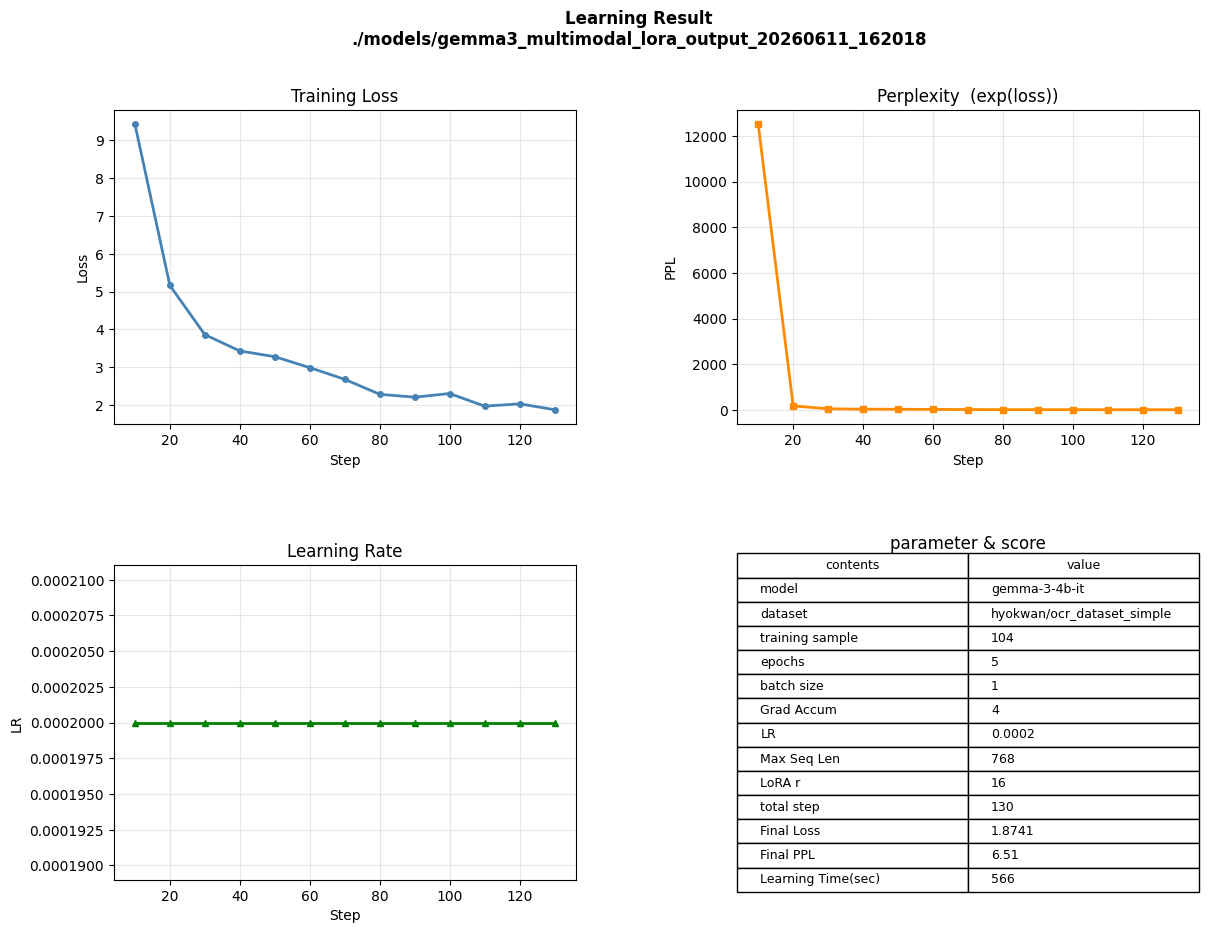

graph save → ./models/gemma3_multimodal_lora_output_20260611_162018/train_result.png


In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 학습 로그 파싱
trainLogs = [x for x in trainer.state.log_history if "loss" in x and "eval_loss" not in x]
trainSteps  = [x["step"]           for x in trainLogs]
trainLosses = [x["loss"]           for x in trainLogs]
trainPpls   = [2.718 ** x["loss"]  for x in trainLogs]   # Perplexity
lrValues    = [x.get("learning_rate", 0) for x in trainLogs]

fig = plt.figure(figsize=(14, 10))
fig.suptitle(f"Learning Result\n{OUTPUT_DIR}", fontsize=12, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ① Loss 곡선
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(trainSteps, trainLosses, color='steelblue', marker='o', markersize=4, linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# ② Perplexity 곡선
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(trainSteps, trainPpls, color='darkorange', marker='s', markersize=4, linewidth=2)
ax2.set_title("Perplexity  (exp(loss))")
ax2.set_xlabel("Step")
ax2.set_ylabel("PPL")
ax2.grid(True, alpha=0.3)

# ③ Learning Rate 곡선
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(trainSteps, lrValues, color='green', marker='^', markersize=4, linewidth=2)
ax3.set_title("Learning Rate")
ax3.set_xlabel("Step")
ax3.set_ylabel("LR")
ax3.grid(True, alpha=0.3)

# ④ 파라미터 요약 테이블
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

lastMetrics = trainer.state.log_history[-1] if trainer.state.log_history else {}
finalLoss   = trainLosses[-1]  if trainLosses else None
finalPpl    = trainPpls[-1]    if trainPpls   else None
trainSec    = lastMetrics.get("train_runtime", None)

tableData = [
    ["model",         BASE_MODEL.split("/")[-1]],
    ["dataset",     DATASET_REPO],
    ["training sample",    len(train_ds)],
    ["epochs",         NUM_EPOCHS],
    ["batch size",    PER_DEVICE_TRAIN_BATCH_SIZE],
    ["Grad Accum",   GRAD_ACCUM],
    ["LR",           LEARNING_RATE],
    ["Max Seq Len",  MAX_SEQ_LENGTH],
    ["LoRA r",       16],
    ["total step",      trainer.state.global_step],
    ["Final Loss",    f"{finalLoss:.4f}" if finalLoss else "-"],
    ["Final PPL",     f"{finalPpl:.2f}"  if finalPpl  else "-"],
    ["Learning Time(sec)", f"{trainSec:.0f}" if trainSec  else "-"],
]

tbl = ax4.table(cellText=tableData, colLabels=["contents", "value"],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.45)
ax4.set_title("parameter & score", pad=12)

plt.savefig(os.path.join(OUTPUT_DIR, "train_result.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"graph save → {OUTPUT_DIR}/train_result.png")

In [51]:

import pandas as pd
from datetime import datetime

COMPARE_CSV = "./models/training_compare.csv"

runRecord = {
    "Exe_Time":    datetime.now().strftime("%Y-%m-%d %H:%M"),
    "output_dir":  OUTPUT_DIR,
    "model":        BASE_MODEL,
    "Dataset":    DATASET_REPO,
    "Sample Size":    len(train_ds),
    "Epochs":        NUM_EPOCHS,
    "Batch_size":    PER_DEVICE_TRAIN_BATCH_SIZE,
    "grad_accum":  GRAD_ACCUM,
    "lr":          LEARNING_RATE,
    "max_seq_len": MAX_SEQ_LENGTH,
    "lora_r":      16,
    "Final_loss":   round(finalLoss, 4) if finalLoss else None,
    "Final_ppl":    round(finalPpl,  2) if finalPpl  else None,
    "Total_Step":      trainer.state.global_step,
    "Learning Time(sec)": round(trainSec, 0) if trainSec else None,
}

newDf = pd.DataFrame([runRecord])
if os.path.exists(COMPARE_CSV):
    prevDf = pd.read_csv(COMPARE_CSV)
    newDf  = pd.concat([prevDf, newDf], ignore_index=True)

newDf.to_csv(COMPARE_CSV, index=False, encoding='utf-8-sig')
print(f"compare table save → {COMPARE_CSV}\n")
display(newDf)

compare table save → ./models/training_compare.csv



,실행시각,output_dir,모델,데이터셋,학습샘플,에폭,배치크기,grad_accum,lr,max_seq_len,...,Exe_Time,model,Dataset,Sample Size,Epochs,Batch_size,Final_loss,Final_ppl,Total_Step,Learning Time(sec)
0,2026-06-11 14:00,./models/gemma3_multimodal_lora_output_2026061...,google/gemma-3-4b-it,hyokwan/ocr_dataset_simple,104.0,5.0,1.0,4,0.0002,768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-11 14:52,./models/gemma3_multimodal_lora_output_2026061...,google/gemma-3-4b-it,hyokwan/ocr_dataset_simple,104.0,5.0,1.0,4,0.0002,768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,./models/gemma3_multimodal_lora_output_2026061...,NaN,NaN,NaN,NaN,NaN,4,0.0002,768,...,2026-06-11 16:32,google/gemma-3-4b-it,hyokwan/ocr_dataset_simple,104.0,5.0,1.0,1.8741,6.51,130.0,566.0


In [52]:
# 학습된 LoRA 어댑터(모델 가중치) 저장
# → 전체 모델이 아니라 "변경된 부분(LoRA)"만 저장됨
trainer.model.save_pretrained(OUTPUT_DIR)

# 멀티모달 전처리기 저장 (tokenizer + image processor 포함)
# → 추론 시 동일한 방식으로 입력 처리하기 위해 필요
processor.save_pretrained(OUTPUT_DIR)

# 저장 완료 로그 출력
print('adapter saved to', OUTPUT_DIR)

adapter saved to ./models/gemma3_multimodal_lora_output_20260611_162018
